<a href="https://colab.research.google.com/github/jillianb2m/tcc-futebol-analise/blob/main/tcc_ml_futebol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Imports

In [4]:
import pandas as pd
import traceback
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from matplotlib.patches import FancyBboxPatch
from scipy.stats import zscore
import scipy.cluster.hierarchy as sch



# 2. Configuração

In [8]:
CONFIG = {
    'DATASET_PATH': '/content/tcc-futebol-analise/datasets/processed/brasileirao_opta_final.csv',
    'POSICAO_ALVO': 'Meia Central',
    'MIN_JOGOS': 5,
    'N_CLUSTERS': 6,
    'METODO_LINKAGE': 'complete'
}

# 3. Github

## 2.1. Clone

In [1]:
%run "/content/drive/MyDrive/Colab Notebooks/tcc-clone-repo.py"

## 2.2. Commit

In [ ]:
#%run "/content/drive/MyDrive/Colab Notebooks/tcc-commit-github.py"

📥 Clonando repositório...
✅ Notebook salvo
📁 Procurando tcc_ml_futebol.ipynb...

📁 Copiando tcc_ml_futebol.ipynb para o repositório...

📂 Arquivos atuais:

===== GIT STATUS =====


KeyboardInterrupt: Interrupted by user

# 4. Coleta e tratamento dos dados

In [ ]:
%run "/content/tcc-futebol-analise/src/scripts/preparar_base.py"


--- Resumo da Bases ---

Base 1
Shape: (17407, 79)

Base 2
Shape: (17282, 73)

Base 3
Shape: (17396, 79)
----------------------

Total de registros: 52,085
Total de colunas: 73
Linhas duplicadas: 4
Duplicatas removidas: 52,081 linhas restantes
  Outro: 16,376 (31.4%)
  Meia Central: 6,926 (13.3%)
  Volante: 6,357 (12.2%)
  Meia Direita: 5,017 (9.6%)
  Meia Esquerda: 4,964 (9.5%)
  Zagueiro: 3,676 (7.1%)
  Meia Atacante: 2,805 (5.4%)
  Goleiro: 2,324 (4.5%)
  Lateral Esquerdo: 930 (1.8%)
  Lateral Direito: 929 (1.8%)
  Ponta Direita: 894 (1.7%)
  Ponta Esquerda: 807 (1.5%)
  Centroavante: 76 (0.1%)

Removidos: 16,376 registros
Restantes: 35,705 registros
Redução: 31.4%


# 5. Clustering

## 5.1. Classe Clustering

### 5.1.1. Inicialização e gerar dataset base

In [9]:
class ClusterBrasileirao:
  def __init__(self, dataset_path):
    self.dataframe = pd.read_csv(dataset_path)
    self.dados_cluster = None
    self.variaveis_metricas = None
    self.dados_padronizados = None

  def gerar_base(self, posicao_alvo=None, min_jogos=5):
    if posicao_alvo:
      df_filtro_alvo = self.dataframe[self.dataframe['Posicao_Real'] == posicao_alvo]
    else:
      df_filtro_alvo = self.dataframe.copy()

    regras_col_agregacao = {
        'rating': 'mean',
        'minutesPlayed': 'sum',
        'totalShots': 'mean',
        'onTargetScoringAttempt': 'mean',
        'bigChanceCreated': 'mean',
        'expectedGoals': 'mean',
        'goals': 'sum',
        'goalAssist': 'sum',
        'totalPass': 'mean',
        'accuratePass': 'mean',
        'keyPass': 'mean',
        'touches': 'mean',
        'possessionLostCtrl': 'mean',
        'totalTackle': 'mean',
        'interceptionWon': 'mean',
        'ballRecovery': 'mean',
        'aerialWon': 'mean',
        'Avg_X': 'mean',
        'Avg_Y': 'mean'
    }

    colunas_existentes = [col for col in regras_col_agregacao.keys() if col in df_filtro_alvo.columns]
    agregacoes_filtradas = {k: v for k, v in regras_col_agregacao.items() if k in colunas_existentes}

    df_agregado_alvo = df_filtro_alvo.groupby(['Jogador', 'Time', 'Posicao_Real']).agg(agregacoes_filtradas).reset_index()

    df_alvo = df_agregado_alvo[df_agregado_alvo['minutesPlayed'] >= min_jogos * 90].copy()

    variaveis_esperadas = [
                            'rating', 'minutesPlayed',
                            'totalPass', 'onTargetScoringAttempt',
                            'bigChanceCreated', 'expectedGoals',
                            'accuratePass', 'touches',
                            'possessionLostCtrl', 'ballRecovery',
                            'totalShots', 'goals',
                            'totalTackle', 'interceptionWon',
                            'keyPass', 'goalAssist', 'aerialWon',
                            'Avg_X', 'Avg_Y'
                          ]

    v_metricas = [v for v in variaveis_esperadas if v in df_alvo.columns]

    self.dados_cluster = df_alvo[['Jogador', 'Time', 'Posicao_Real'] + v_metricas].copy()

    self.variaveis_metricas = v_metricas
    dados_metricos = self.dados_cluster[v_metricas].copy()

    return dados_metricos

### 5.1.2. Análise Exploratória

In [10]:
def explorar_variaveis_dataframe(self):
    print("********* Análise Exploratória *********")

    pd.set_option('display.max_columns', None)
    pd.set_option('display.expand_frame_repr', False)

    print(self.dados_cluster[self.variaveis_metricas].describe().round(2))
    print("\n")

    fig, axes = plt.subplots(3, 3, figsize=(24, 16))
    fig.suptitle('Distribuição das Variáveis de Desempenho', fontsize=18)

    if 'minutesPlayed' in self.variaveis_metricas:
        dados_melt_1 = pd.melt(self.dados_cluster[['minutesPlayed']])
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_1, ax=axes[0,0], palette='viridis', legend=False)
        axes[0,0].set_title('Minutos Jogados', fontsize=14)
        axes[0,0].set_ylabel('Minutos', fontsize=12)

    v_nivel_altissimo = ['totalPass', 'accuratePass']
    v_disponiveis_altissimo = [v for v in v_nivel_altissimo if v in self.variaveis_metricas]
    if v_disponiveis_altissimo:
        dados_melt_2 = pd.melt(self.dados_cluster[v_disponiveis_altissimo])
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_2, ax=axes[0,1], palette='viridis', legend=False)
        axes[0,1].set_title('Passes', fontsize=14)
        axes[0,1].set_ylabel('Valores por Jogo (20-60)', fontsize=12)
        axes[0,1].tick_params(axis='x', rotation=45)

    v_nivel_medio = ['totalTackle', 'keyPass']
    v_disponiveis_medio = [v for v in v_nivel_medio if v in self.variaveis_metricas]
    if v_disponiveis_medio:
        dados_melt_3 = pd.melt(self.dados_cluster[v_disponiveis_medio])
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_3, ax=axes[0,2], palette='viridis', legend=False)
        axes[0,2].set_title('Desarmes e Assistência (não gol)', fontsize=14)
        axes[0,2].set_ylabel('Valores por Jogo (0-8)', fontsize=12)
        axes[0,2].tick_params(axis='x', rotation=45)

    if 'rating' in self.variaveis_metricas:
        dados_melt_4 = pd.melt(self.dados_cluster[['rating']])
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_4, ax=axes[1,0], palette='viridis', legend=False)
        axes[1,0].set_title('Rating (Desempenho)', fontsize=14)
        axes[1,0].set_ylabel('Rating (6-8)', fontsize=12)

    v_assist_shots = ['goalAssist', 'totalShots']
    v_disponiveis_assist = [v for v in v_assist_shots if v in self.variaveis_metricas]
    if v_disponiveis_assist:
        dados_melt_5 = pd.melt(self.dados_cluster[v_disponiveis_assist])
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_5, ax=axes[1,1], palette='viridis', legend=False)
        axes[1,1].set_title('Assistências e Finalizações', fontsize=14)
        axes[1,1].set_ylabel('Valores por Jogo (0-5)', fontsize=12)
        axes[1,1].tick_params(axis='x', rotation=45)

    if 'goals' in self.variaveis_metricas:
        dados_melt_6 = pd.melt(self.dados_cluster[['goals']])
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_6, ax=axes[1,2], palette='viridis', legend=False)
        axes[1,2].set_title('Gols', fontsize=14)
        axes[1,2].set_ylabel('Gols por Jogo (0-20)', fontsize=12)

    if 'interceptionWon' in self.variaveis_metricas:
        dados_melt_7 = pd.melt(self.dados_cluster[['interceptionWon']])
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_7, ax=axes[2,0], palette='viridis', legend=False)
        axes[2,0].set_title('Interceptações', fontsize=14)
        axes[2,0].set_ylabel('Interceptações por Jogo (0-5)', fontsize=12)

    v_posicao = ['Avg_X', 'Avg_Y']
    v_disponiveis_posicao = [v for v in v_posicao if v in self.variaveis_metricas]
    if v_disponiveis_posicao:
        dados_melt_8 = pd.melt(self.dados_cluster[v_disponiveis_posicao])
        dados_melt_8['variable'] = dados_melt_8['variable'].replace({
            'Avg_X': 'Posição Horizontal',
            'Avg_Y': 'Posição Vertical'
        })
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_8, ax=axes[2,1], palette='viridis', legend=False)
        axes[2,1].set_title('Posicionamento em Campo', fontsize=14)
        axes[2,1].set_ylabel('Coordenadas (0-100)', fontsize=12)

    axes[2,2].axis('off')
    axes[2,2].set_title('Legenda - Posicionamento em Campo', fontsize=14)

    texto_legenda = (
                        "Horizontal (Posição X):\n"
                        "• 0 = Lado Esquerdo\n"
                        "• 50 = Centro do Campo\n"
                        "• 100 = Lado Direito\n\n"
                        "Vertical (Posição Y):\n"
                        "• 0 = Linha de Ataque\n"
                        "• 50 = Linha do Meio Campo\n"
                        "• 100 = Linha de Defesa\n\n"
                        "Exemplos:\n"
                        "• Goleiro: (50, 90)\n"
                        "• Zagueiro: (50, 75)\n"
                        "• Volante: (50, 60)\n"
                        "• Meia: (50, 40)\n"
                        "• Atacante: (50, 20)"
                    )

    rect = FancyBboxPatch((0.1, 0.15), 0.8, 0.7,
                          transform=axes[2,2].transAxes,
                          facecolor='lightblue', alpha=0.9,
                          edgecolor='navy', linewidth=2.0,
                          boxstyle='round,pad=0.5')
    axes[2,2].add_patch(rect)

    axes[2,2].text(0.15, 0.50, texto_legenda, transform=axes[2,2].transAxes,
                  fontsize=14, ha='left', va='center')

    plt.tight_layout()
    plt.savefig('boxplot_variaveis_melhorado.png', dpi=300, bbox_inches='tight')
    plt.show()

ClusterBrasileirao.explorar_variaveis_dataframe = explorar_variaveis_dataframe

### 5.1.3. Padronização dos Dados (ZScore ou StandardScaler)

In [11]:
def padronizar_dados(self, metodo='zscore'):

    dados_metricos = self.dados_cluster[self.variaveis_metricas].copy()

    if metodo == 'zscore':
        self.dados_padronizados = dados_metricos.apply(zscore, ddof=1)
        print("Padronização Z-Score aplicada")
    else:
        scaler = StandardScaler()
        self.dados_padronizados = pd.DataFrame(scaler.fit_transform(dados_metricos),
                                               columns=dados_metricos.columns,
                                               index=dados_metricos.index
                                              )
        print("Padronização StandardScaler aplicada")

    print("\nMédias após padronização (devem ser ~0):")
    print(self.dados_padronizados.mean())
    print("\nDesvios padrão após padronização (devem ser ~1):")
    print(self.dados_padronizados.std())

    return self.dados_padronizados

ClusterBrasileirao.padronizar_dados = padronizar_dados

### 5.1.4. Método Elbow

In [12]:
def analisar_elbow(self, max_clusters=8, random_state=100):

    elbow = []
    K = range(1, max_clusters + 1)

    for k in K:
      kmeans_elbow = KMeans(n_clusters=k, init='random',
                            random_state=random_state
                            ).fit(self.dados_padronizados)

      elbow.append(kmeans_elbow.inertia_)

    plt.figure(figsize=(12, 8), dpi=600)
    plt.plot(K, elbow, marker='o', linewidth=2, markersize=8)
    plt.xlabel('Nº Clusters', fontsize=16)
    plt.xticks(range(1, max_clusters + 1))
    plt.ylabel('WCSS', fontsize=16)
    plt.title('Método de Elbow', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('metodo_elbow.png', dpi=300, bbox_inches='tight')
    plt.show()

    quedas = []
    for i in range(1, len(elbow)):
      queda_percentual = ((elbow[i-1] - elbow[i]) / elbow[i-1]) * 100
      quedas.append(queda_percentual)

    if quedas:
      cotovelo_sugerido = quedas.index(max(quedas)) + 2
      print(f"Nº sugerido de clusters (cotovelo): {cotovelo_sugerido}")
      return cotovelo_sugerido

    return 3

ClusterBrasileirao.analisar_elbow = analisar_elbow

### 5.1.5. Clustering Hierárquico

In [13]:
def aplicar_hierarquico(self, n_clusters=3, metodo_linkage='average', metrica_distancia='euclidean'):

      print(f"\n********** Algoritmo Hierárquico ({metodo_linkage} linkage) **********")

      plt.figure(figsize=(16, 8), dpi=600)
      linkage_matrix = sch.linkage(self.dados_padronizados, method=metodo_linkage, metric=metrica_distancia)

      labels_jogadores = [f"{jog}"[:15] for jog in self.dados_cluster['Jogador'].values]
      dendrogram = sch.dendrogram(linkage_matrix, labels=labels_jogadores, color_threshold=6)

      plt.title(f'Dendrograma - {metodo_linkage.title()} Linkage', fontsize=16)
      plt.xlabel('Jogadores', fontsize=16)
      plt.ylabel(f'Distância {metrica_distancia.title()}', fontsize=16)
      plt.axhline(y=6, color='red', linestyle='--')
      plt.xticks(rotation=90)
      plt.tight_layout()
      plt.savefig(f'dendrograma_{metodo_linkage}.png', dpi=300, bbox_inches='tight')
      plt.show()

      cluster_hierarquico = AgglomerativeClustering(n_clusters=n_clusters,
                                                    metric=metrica_distancia,
                                                    linkage=metodo_linkage
                                                    )

      indicadores_cluster = cluster_hierarquico.fit_predict(self.dados_padronizados)
      self.dados_cluster[f'cluster_hierarchical_{metodo_linkage}'] = indicadores_cluster
      self.dados_cluster[f'cluster_hierarchical_{metodo_linkage}'] = self.dados_cluster[f'cluster_hierarchical_{metodo_linkage}'].astype('category')

      coeficientes = [y[1] for y in dendrogram['dcoord']]
      print(f"Coeficientes de aglomeração ({metodo_linkage}): {coeficientes[:5]}...")

      print(f"\nDistribuição dos clusters ({metodo_linkage}):")
      for i in range(n_clusters):
          count = (indicadores_cluster == i).sum()
          percent = (count / len(indicadores_cluster)) * 100
          print(f"Cluster {i}: {count} jogadores ({percent:.1f}%)")

      return indicadores_cluster

ClusterBrasileirao.aplicar_hierarquico = aplicar_hierarquico

### 5.1.6. Clustering K-Means

In [14]:
def aplicar_kmeans(self, n_clusters=3, init_method='random', random_state=100):
      print(f"\n********** Algoritmo K-MEANS (k={n_clusters}) **********")

      kmeans = KMeans(n_clusters=n_clusters,
                      init=init_method,
                      random_state=random_state
                      ).fit(self.dados_padronizados)

      kmeans_clusters = kmeans.labels_
      self.dados_cluster['cluster_kmeans'] = kmeans_clusters
      self.dados_cluster['cluster_kmeans'] = self.dados_cluster['cluster_kmeans'].astype('category')

      self.centroides = pd.DataFrame(kmeans.cluster_centers_)
      self.centroides.columns = self.variaveis_metricas
      self.centroides.index.name = 'cluster'

      print("\nCentroides dos clusters:")
      print(self.centroides.round(3))

      if len(self.variaveis_metricas) >= 2:
          plt.figure(figsize=(10, 8), dpi=600)

          var1, var2 = self.variaveis_metricas[0], self.variaveis_metricas[1]

          sns.scatterplot(data=self.dados_cluster, x=var1, y=var2,
                          hue='cluster_kmeans', palette='viridis', s=100)

          centroides_plot = self.centroides[[var1, var2]].copy()

          sns.scatterplot(data=centroides_plot, x=var1, y=var2, c='red',
                          label='Centróides', marker="X", s=200)

          plt.title('Clusters e Centroides', fontsize=16)
          plt.xlabel(var1.replace('_', ' ').title(), fontsize=14)
          plt.ylabel(var2.replace('_', ' ').title(), fontsize=14)
          plt.legend()
          plt.grid(True, alpha=0.3)
          plt.tight_layout()
          plt.savefig('clusters_centroides.png', dpi=300, bbox_inches='tight')
          plt.show()

      return kmeans_clusters

ClusterBrasileirao.aplicar_kmeans = aplicar_kmeans

## 5.2. Função main

Padronização StandardScaler aplicada

Médias após padronização (devem ser ~0):
rating                   -2.391250e-15
minutesPlayed            -2.049643e-17
totalPass                -4.816660e-16
onTargetScoringAttempt   -1.810518e-16
bigChanceCreated          2.254607e-16
expectedGoals             1.605553e-16
accuratePass              2.049643e-17
touches                  -2.954901e-16
possessionLostCtrl       -7.412874e-16
ballRecovery             -2.767017e-16
totalShots               -1.878839e-16
goals                     1.366428e-17
totalTackle               1.895919e-16
interceptionWon           2.152125e-16
keyPass                  -8.881784e-17
goalAssist               -8.540177e-18
aerialWon                -1.195625e-17
Avg_X                    -2.090635e-15
Avg_Y                     3.065924e-16
dtype: float64

Desvios padrão após padronização (devem ser ~1):
rating                    1.001929
minutesPlayed             1.001929
totalPass                 1.001929
onTargetSc

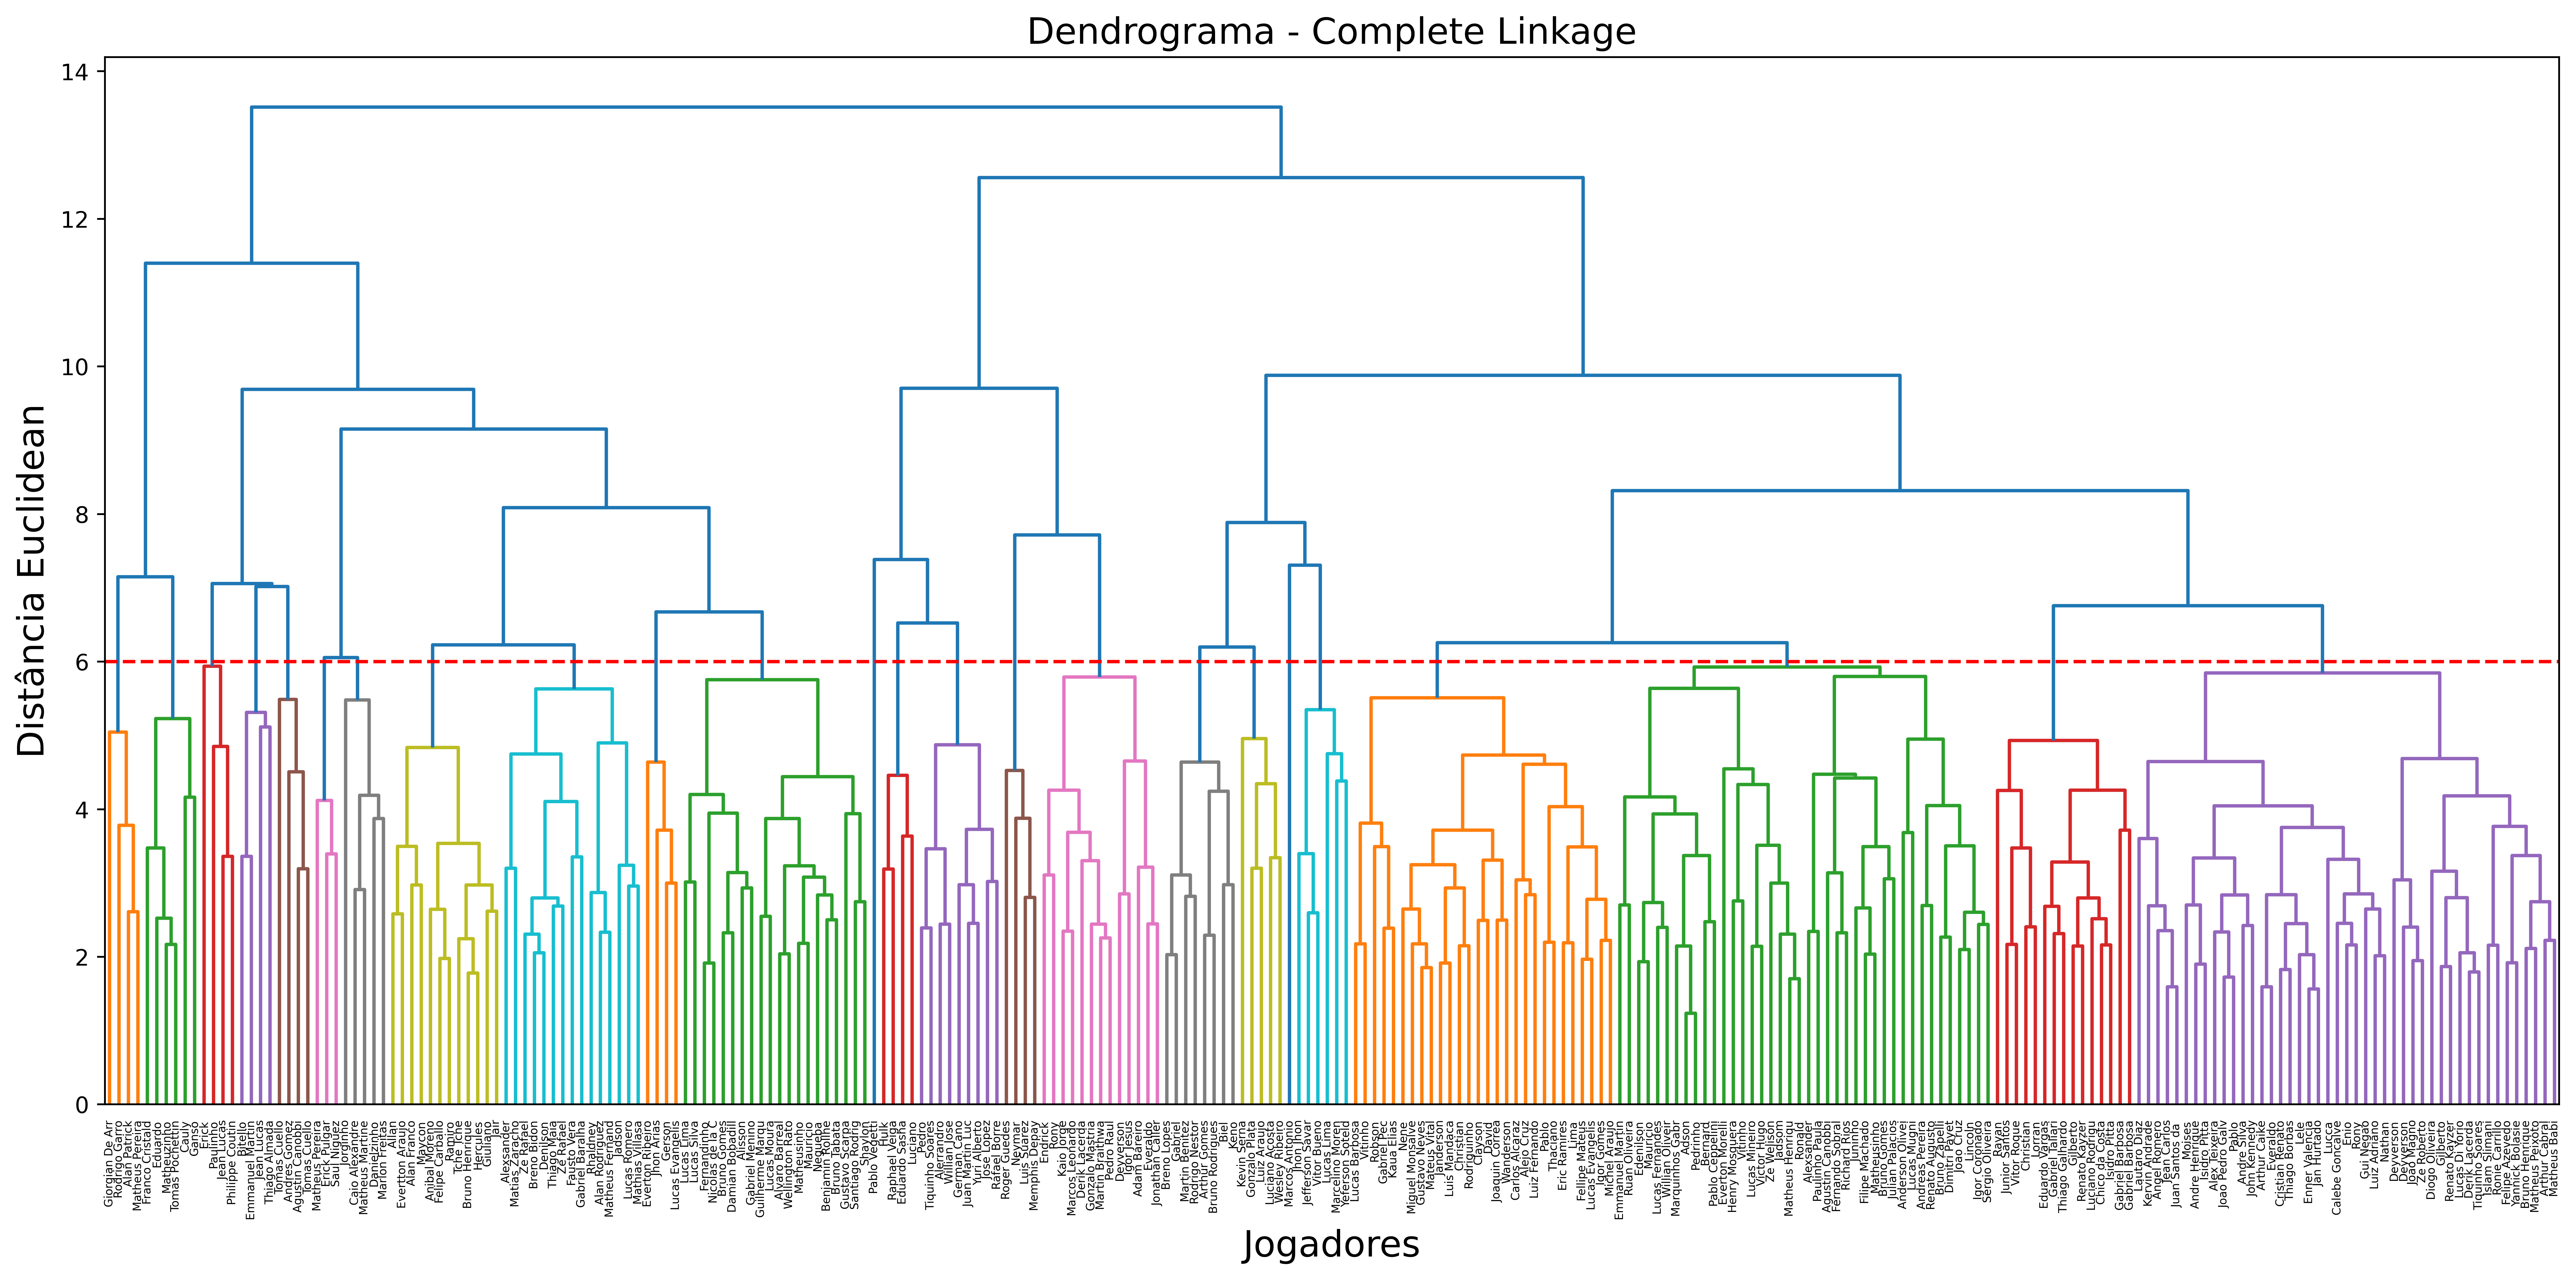

Coeficientes de aglomeração (complete): [np.float64(2.6123669879112983), np.float64(3.78406682818386), np.float64(5.04396962110124), np.float64(2.169821814473587), np.float64(2.5233340586207915)]...

Distribuição dos clusters (complete):
Cluster 0: 71 jogadores (27.3%)
Cluster 1: 20 jogadores (7.7%)
Cluster 2: 128 jogadores (49.2%)
Cluster 3: 10 jogadores (3.8%)
Cluster 4: 17 jogadores (6.5%)
Cluster 5: 14 jogadores (5.4%)


In [15]:
# Cell 8: Função Principal
def main(pos_alvo="Meia Central", min_jogos=5):

  resultado_final = ClusterBrasileirao('/content/tcc-futebol-analise/datasets/processed/brasileirao_opta_final.csv')

  try:
    dados_metricos_result = resultado_final.gerar_base(pos_alvo, min_jogos)
  except Exception as e:
    print('Erro ao gerar dados métricos: ' + traceback.format_exc())

  #resultado_final.explorar_variaveis_dataframe()

  dados_padronizados = resultado_final.padronizar_dados(metodo='sklearn')

  #k_ideal = resultado_final.analisar_elbow(max_clusters=8)

  #resultado_final.aplicar_hierarquico(n_clusters=k_ideal, metodo_linkage='average')
  resultado_final.aplicar_hierarquico(n_clusters=6, metodo_linkage='complete')

  #resultado_final.aplicar_kmeans(n_clusters=k_ideal)

  return dados_metricos_result

if __name__ == "__main__":
    dados_metricos = main()